
# 💊 Project 1: Pharmaceutical Sales Data Analysis (2014 – 2019)
**Author:** Riya Vadadoria  

This notebook explores six years of daily **pharmaceutical sales data (2014 – 2019)** to uncover meaningful trends, seasonal patterns, and relationships among different **ATC drug categories**.  
The goal is to transform raw sales data into actionable insights that help pharmacies and healthcare providers make **data-driven decisions** for inventory planning and forecasting.  

The dataset `salesdaily.csv` contains sales records for eight ATC therapeutic categories, including **pain relief, respiratory, and mental health medications**.  
Through analysis and visualization, this project reveals how pharmaceutical demand changes over time across categories, months, and years.  

---

### 📋 Workflow Overview  

1. **Data Cleaning and Preparation**  
  - Loaded and cleaned the dataset using **pandas**.  
  - Standardized column names and parsed the date field for time-based grouping.  
  - Created a **`total_sales`** column to summarize all ATC category sales.  
  - Checked for missing values and duplicates to ensure data integrity.  

2. **Exploratory Data Analysis (EDA)**  
  - Analyzed **monthly and yearly sales patterns** to reveal long-term trends.  
  - Calculated **Year-over-Year (YoY)** percentage changes to highlight growth or decline.  
  - Compared total sales across categories to identify **top-selling drug types**.  

3. **Seasonality and Weekly Patterns**  
  - Examined average sales by **month** and **weekday** to uncover recurring demand cycles.  
  - Visualized results using bar and line charts for clear interpretation.  

4. **Correlation Analysis**  
  - Created a **heatmap** to explore relationships among ATC categories.  
  - Identified which categories tend to rise or fall together over time.  

---

### 🎯 Project Goal  
The goal of this project is to apply **data mining and visualization techniques** to uncover hidden insights in pharmaceutical sales data.  
By understanding how drug demand shifts throughout the year, this analysis supports better **business planning, healthcare forecasting, and inventory optimization**.  


In [9]:
import pandas as pd

In [10]:
pharma_sales = pd.read_csv("salesdaily.csv")

In [11]:
print(pharma_sales.head())

      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  


In [6]:
print(pharma_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB
None


In [13]:
# Used pandas string methods to clean column names
pharma_sales.columns = (
    pharma_sales.columns
    .str.strip()              # remove leading/trailing spaces
    .str.lower()              # convert to lowercase
    .str.replace(" ", "_")    # replace spaces with underscores
)

In [14]:
# Parse datum into a datetime column called date
pharma_sales["date"] = pd.to_datetime(pharma_sales["datum"])

In [15]:
print(pharma_sales.head())

      datum  m01ab  m01ae  n02ba  n02be  n05b  n05c   r03  r06  year  month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   hour weekday_name       date  
0   248     Thursday 2014-01-02  
1   276       Friday 2014-01-03  
2   276     Saturday 2014-01-04  
3   276       Sunday 2014-01-05  
4   276       Monday 2014-01-06  


In [16]:
print(pharma_sales.dtypes)

datum                   object
m01ab                  float64
m01ae                  float64
n02ba                  float64
n02be                  float64
n05b                   float64
n05c                   float64
r03                    float64
r06                    float64
year                     int64
month                    int64
hour                     int64
weekday_name            object
date            datetime64[ns]
dtype: object


In [18]:
# Added a total_sales column by summing the 8 ATC category columns
pharma_sales["total_sales"] = (
    pharma_sales["m01ab"] +
    pharma_sales["m01ae"] +
    pharma_sales["n02ba"] +
    pharma_sales["n02be"] +
    pharma_sales["n05b"] +
    pharma_sales["n05c"] +
    pharma_sales["r03"] +
    pharma_sales["r06"]
)

# result
print(pharma_sales[["date", "total_sales"]].head())

        date  total_sales
0 2014-01-02        48.47
1 2014-01-03       107.00
2 2014-01-04        91.35
3 2014-01-05        66.10
4 2014-01-06        58.20


In [19]:
#total missing values in the dataset
print("Total missing values:", pharma_sales.isna().sum().sum())

Total missing values: 0


In [20]:
# Counted total duplicate rows in the dataset
print("Number of duplicate rows:", pharma_sales.duplicated().sum())

Number of duplicate rows: 0


In [23]:
# --- Monthly totals ---
# Group by month and sum total_sales
monthly_sales = pharma_sales.groupby(pharma_sales["date"].dt.to_period("M"))["total_sales"].sum()
monthly_sales

date
2014-01    1801.110000
2014-02    1974.470000
2014-03    1606.720000
2014-04    1423.925000
2014-05    1506.303000
              ...     
2019-06    1482.407000
2019-07    1488.816000
2019-08    1377.779000
2019-09    1824.803667
2019-10     538.600000
Freq: M, Name: total_sales, Length: 70, dtype: float64

In [24]:
# --- Yearly totals ---
# Group by year and sum total_sales
yearly_sales = pharma_sales.groupby(pharma_sales["date"].dt.year)["total_sales"].sum()
yearly_sales

date
2014    20238.337687
2015    22752.358000
2016    25234.926000
2017    19399.365667
2018    22884.561000
2019    17085.955333
Name: total_sales, dtype: float64

In [26]:
# --- Year-over-Year % change ---
# Calculate YoY growth/decline in percentage
yearly_yoy = yearly_sales.pct_change() * 100
yearly_yoy 

date
2014          NaN
2015    12.422069
2016    10.911256
2017   -23.124935
2018    17.965512
2019   -25.338505
Name: total_sales, dtype: float64

In [27]:
# Derive month number from the date column
pharma_sales["month_from_date"] = pharma_sales["date"].dt.month

# Derive weekday name from the date column
pharma_sales["weekday_from_date"] = pharma_sales["date"].dt.day_name()

#checking
print(pharma_sales[["date", "month_from_date", "weekday_from_date"]].head())

        date  month_from_date weekday_from_date
0 2014-01-02                1          Thursday
1 2014-01-03                1            Friday
2 2014-01-04                1          Saturday
3 2014-01-05                1            Sunday
4 2014-01-06                1            Monday


<Axes: title={'center': 'Total Sales by ATC Category'}>

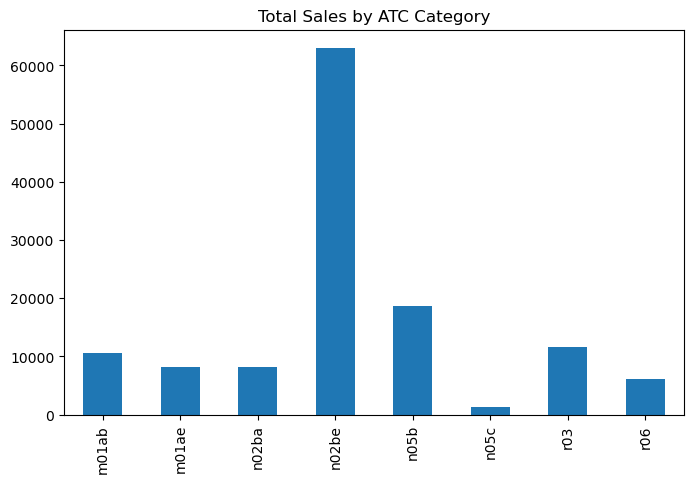

In [28]:
# Total sales per ATC category
category_totals = pharma_sales[["m01ab","m01ae","n02ba","n02be","n05b","n05c","r03","r06"]].sum()

# Plot bar chart
category_totals.plot(kind="bar", figsize=(8,5), title="Total Sales by ATC Category")


<Axes: title={'center': 'Yearly Total Sales'}, xlabel='date'>

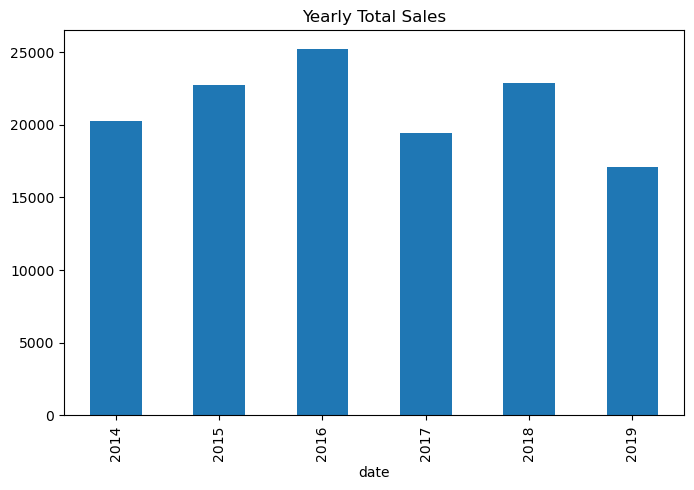

In [29]:
# Yearly totals
yearly_sales = pharma_sales.groupby(pharma_sales["date"].dt.year)["total_sales"].sum()

# Plot bar chart
yearly_sales.plot(kind="bar", figsize=(8,5), title="Yearly Total Sales")


<Axes: title={'center': 'Year-over-Year % Change'}, xlabel='date'>

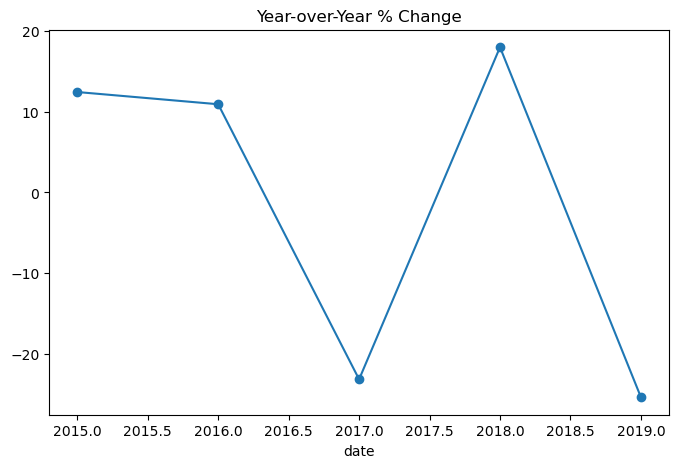

In [30]:
yearly_yoy = yearly_sales.pct_change() * 100
yearly_yoy.plot(kind="line", marker="o", figsize=(8,5), title="Year-over-Year % Change")


<Axes: title={'center': 'Average Sales by Month'}, xlabel='date'>

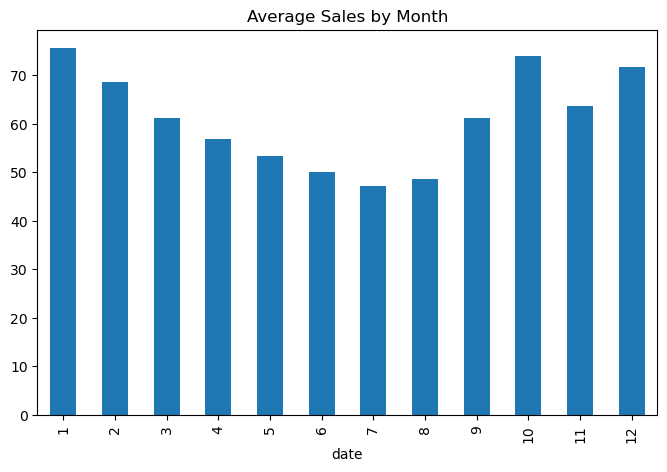

In [31]:
# Average sales per calendar month (across all years)
monthly_pattern = pharma_sales.groupby(pharma_sales["date"].dt.month)["total_sales"].mean()

# Plot bar chart
monthly_pattern.plot(kind="bar", figsize=(8,5), title="Average Sales by Month")


<Axes: title={'center': 'Average Sales by Weekday'}, xlabel='date'>

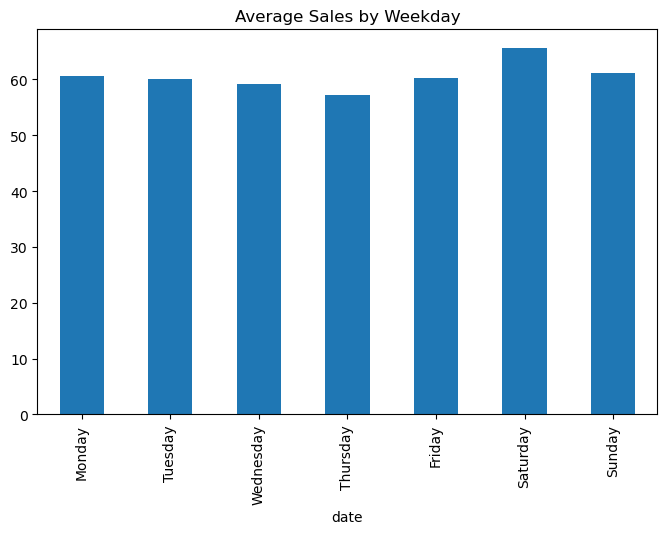

In [32]:
# Average sales per weekday
weekday_pattern = pharma_sales.groupby(pharma_sales["date"].dt.day_name())["total_sales"].mean()

# Reorder weekdays
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_pattern = weekday_pattern.reindex(weekday_order)

# Plot bar chart
weekday_pattern.plot(kind="bar", figsize=(8,5), title="Average Sales by Weekday")


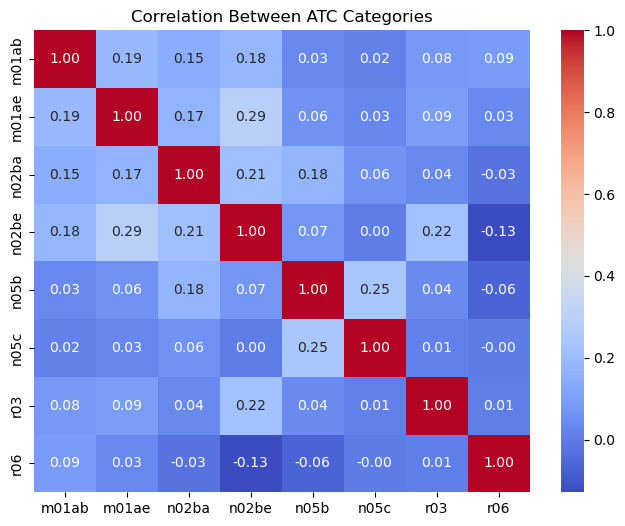

In [33]:
# Correlation between ATC categories
category_corr = pharma_sales[["m01ab","m01ae","n02ba","n02be","n05b","n05c","r03","r06"]].corr()

# Plot heatmap 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(category_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between ATC Categories")
plt.show()
